# 用户价值分层 — 增强RFM模型（引入意向度与转化摩擦系数）

## 业务背景
- **老用户复购持续下降**，需要识别出沉默流失风险群体
- **部分新用户频繁浏览但购买很少或不购买**（潜水用户），传统RFM会将其判为低价值，造成潜在用户流失
- 引入**意向度**和**转化摩擦系数**两个新指标，更精准地识别高潜力未转化用户

## 新增指标定义
- **意向度 (Intent Score)** = 浏览时长 × 0.5 + 浏览页数 × 0.5
  - 衡量用户的浏览深度和兴趣强度，越高说明用户对平台内容越感兴趣
- **转化摩擦系数 (Conversion Friction)** = 购买次数 / (1 + 浏览页数)
  - 反映用户从浏览到购买的转化效率，值越低说明用户浏览多但买得少（摩擦力大），越需要运营干预

## 聚类维度
使用 **R、F、M、意向度、转化摩擦系数** 五个维度进行K-Means聚类，实现更精细的用户分层。


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
sns.set_palette('Set2')
print('库导入完成')


库导入完成


In [44]:
df = pd.read_excel('user_personalized_features.xlsx')
print(f'数据集大小: {df.shape}')
print(f'用户数: {len(df)}')
df.head(10)


数据集大小: (1000, 12)
用户数: 1000


,User_ID,Age,Gender,Location,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,#1,56,Male,Suburban,5,7,18,2546,Books,584,38,True
1,#2,46,Female,Rural,15,7,118,320,Electronics,432,40,False
2,#3,32,Female,Suburban,28,1,146,3766,Apparel,306,1,True
3,#4,60,Female,Suburban,18,3,163,4377,Apparel,527,29,False
4,#5,25,Male,Suburban,2,5,141,4502,Health & Beauty,53,10,True
5,#6,38,Male,Suburban,22,8,25,2669,Books,520,28,False
6,#7,56,Male,Urban,11,7,152,1113,Home & Kitchen,330,31,True
7,#8,36,Male,Urban,26,7,108,2151,Apparel,558,19,True
8,#9,40,Male,Rural,25,6,130,4085,Books,325,3,True
9,#10,28,Male,Urban,13,8,61,4999,Electronics,114,36,False


In [45]:
print('=== 数据描述统计 ===')
display(df.describe())
print()
print('=== 缺失值检查 ===')
display(df.isnull().sum().to_frame('缺失数'))
print()
print('=== 分类型变量分布 ===')
display(df[['Gender','Location','Product_Category_Preference','Newsletter_Subscription']].describe())


=== 数据描述统计 ===


,Age,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Time_Spent_on_Site_Minutes,Pages_Viewed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,40.986000,15.586000,4.631000,104.039000,2552.957000,297.360000,24.40300
std,13.497852,8.205604,2.837762,54.873569,1420.985048,175.596123,14.02017
min,18.000000,1.000000,0.000000,10.000000,112.000000,2.000000,1.00000
25%,29.000000,8.000000,2.000000,58.000000,1271.750000,144.000000,12.00000
50%,42.000000,16.000000,5.000000,105.000000,2542.000000,292.500000,24.50000
75%,52.000000,23.000000,7.000000,150.000000,3835.500000,449.250000,36.00000
max,64.000000,29.000000,9.000000,199.000000,4999.000000,599.000000,49.00000



=== 缺失值检查 ===


,缺失数
User_ID,0
Age,0
Gender,0
Location,0
Last_Login_Days_Ago,0
Purchase_Frequency,0
Average_Order_Value,0
Total_Spending,0
Product_Category_Preference,0
Time_Spent_on_Site_Minutes,0



=== 分类型变量分布 ===


,Gender,Location,Product_Category_Preference,Newsletter_Subscription
count,1000,1000,1000,1000
unique,2,3,5,2
top,Male,Suburban,Apparel,True
freq,526,349,218,507


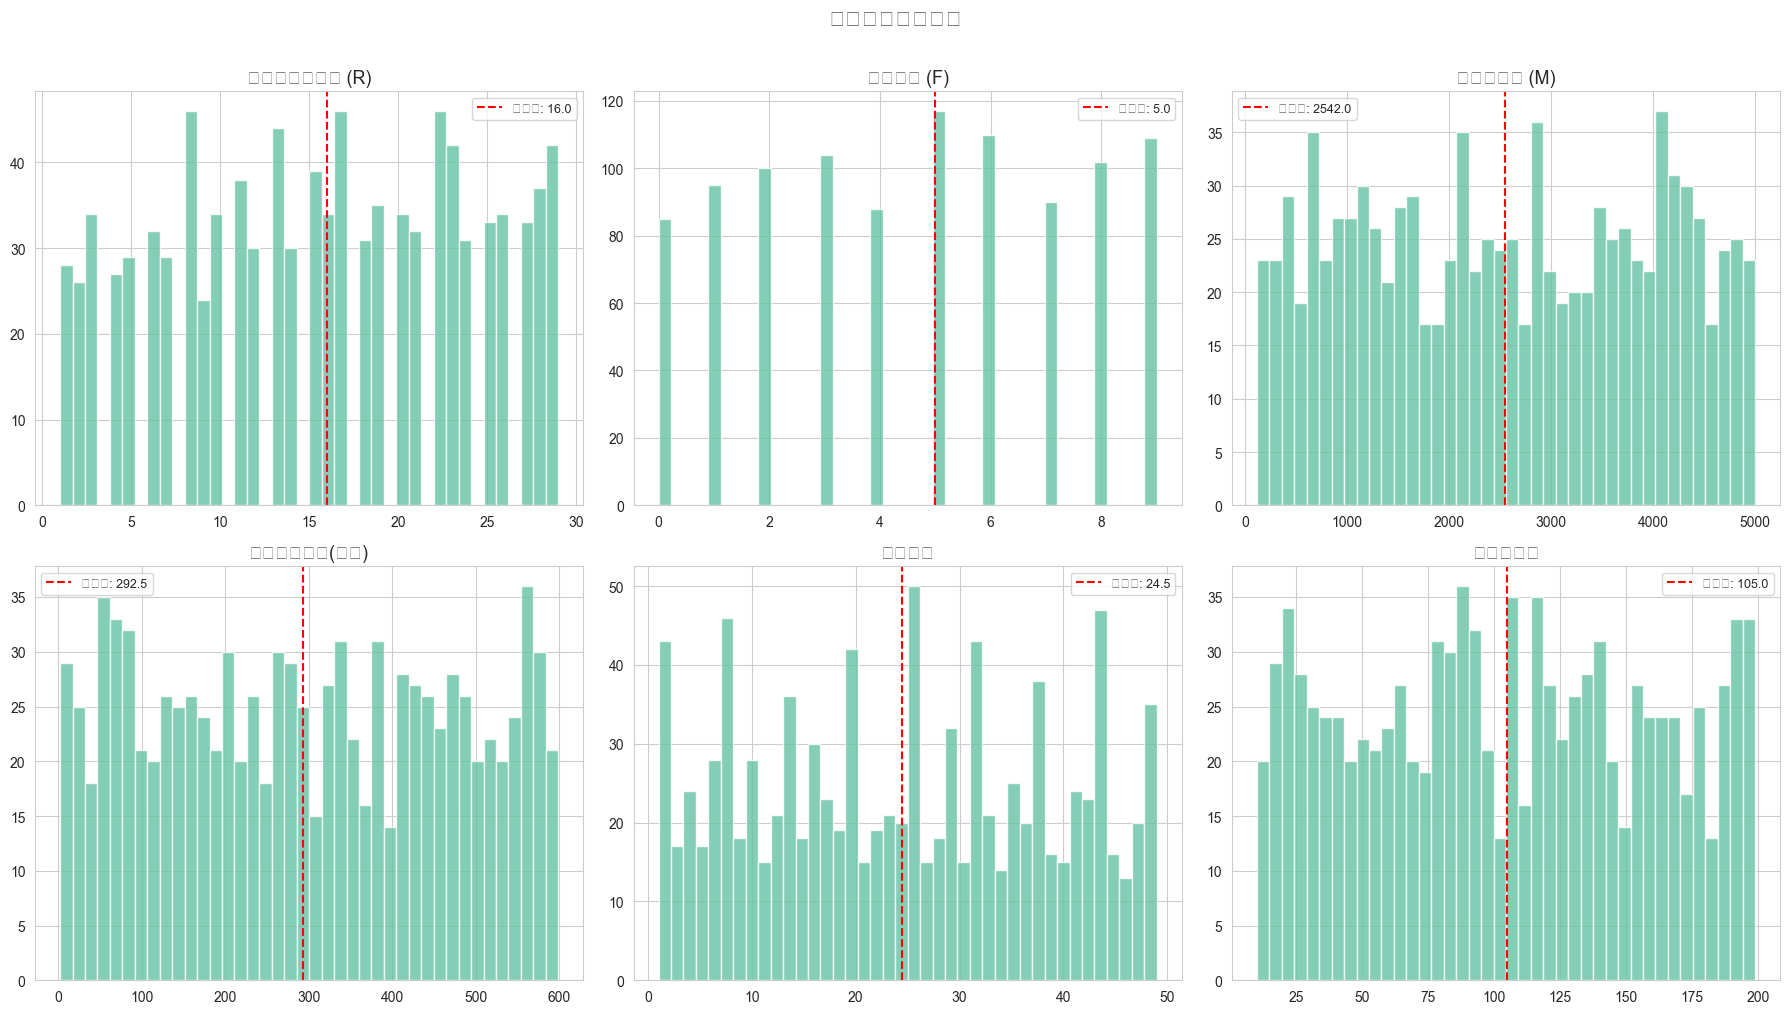

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cols = ['Last_Login_Days_Ago','Purchase_Frequency','Total_Spending',
        'Time_Spent_on_Site_Minutes','Pages_Viewed','Average_Order_Value']
titles = ['距上次登录天数 (R)','购买频次 (F)','总消费金额 (M)',
          '网站浏览时长(分钟)','浏览页数','平均客单价']
for i, (col, title) in enumerate(zip(cols, titles)):
    ax = axes[i//3, i%3]
    ax.hist(df[col], bins=40, edgecolor='white', alpha=0.8)
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'中位数: {df[col].median():.1f}')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
plt.suptitle('核心指标分布概览', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


---
## 1. 特征工程：构建意向度与转化摩擦系数


In [47]:
# ============================================
# 新指标计算
# ============================================
df['Intent_Score'] = df['Time_Spent_on_Site_Minutes'] * 0.5 + df['Pages_Viewed'] * 0.5
df['Conversion_Friction'] = df['Purchase_Frequency'] / (1 + df['Pages_Viewed'])

print('=== 新增指标 ===')
print('意向度 (Intent Score) = 浏览时长 x 0.5 + 浏览页数 x 0.5')
print('转化摩擦系数 (Conversion Friction) = 购买次数 / (1 + 浏览页数)')
print()
display(df[['User_ID','Time_Spent_on_Site_Minutes','Pages_Viewed','Intent_Score',
            'Purchase_Frequency','Conversion_Friction']].head(10))
print()
print(f'意向度范围: [{df.Intent_Score.min():.1f}, {df.Intent_Score.max():.1f}]'
      f'  均值: {df.Intent_Score.mean():.1f}  中位数: {df.Intent_Score.median():.1f}')
print(f'转化摩擦系数范围: [{df.Conversion_Friction.min():.4f}, {df.Conversion_Friction.max():.4f}]'
      f'  均值: {df.Conversion_Friction.mean():.4f}  中位数: {df.Conversion_Friction.median():.4f}')


=== 新增指标 ===
意向度 (Intent Score) = 浏览时长 x 0.5 + 浏览页数 x 0.5
转化摩擦系数 (Conversion Friction) = 购买次数 / (1 + 浏览页数)



,User_ID,Time_Spent_on_Site_Minutes,Pages_Viewed,Intent_Score,Purchase_Frequency,Conversion_Friction
0,#1,584,38,311.0,7,0.179487
1,#2,432,40,236.0,7,0.170732
2,#3,306,1,153.5,1,0.500000
3,#4,527,29,278.0,3,0.100000
4,#5,53,10,31.5,5,0.454545
5,#6,520,28,274.0,8,0.275862
6,#7,330,31,180.5,7,0.218750
7,#8,558,19,288.5,7,0.350000
8,#9,325,3,164.0,6,1.500000
9,#10,114,36,75.0,8,0.216216



意向度范围: [1.5, 321.0]  均值: 160.9  中位数: 158.2
转化摩擦系数范围: [0.0000, 4.5000]  均值: 0.3246  中位数: 0.1837


In [48]:
# 潜水用户挖掘：高意向度 + 低转化摩擦系数 = 浏览多但买得少
intent_med = df['Intent_Score'].median()
fric_med = df['Conversion_Friction'].median()
freq_med = df['Purchase_Frequency'].median()

l1 = df[(df['Intent_Score'] > intent_med) & (df['Conversion_Friction'] < fric_med)]
l2 = df[(df['Intent_Score'] > intent_med) & (df['Purchase_Frequency'] < freq_med)]
l3 = df[(df['Intent_Score'] > intent_med) & (df['Purchase_Frequency'] == 0)]

print('【潜水用户识别】')
print(f'类型A — 高意向+高转化摩擦(低转化效率): {len(l1)}人 ({len(l1)/len(df)*100:.1f}%)')
print(f'  平均浏览时长: {l1.Time_Spent_on_Site_Minutes.mean():.0f}分钟'
      f'  (全量均值: {df.Time_Spent_on_Site_Minutes.mean():.0f}分钟)')
print(f'  平均浏览页数: {l1.Pages_Viewed.mean():.0f}页'
      f'  (全量均值: {df.Pages_Viewed.mean():.0f}页)')
print(f'  平均购买次数: {l1.Purchase_Frequency.mean():.1f}次'
      f'  (全量均值: {df.Purchase_Frequency.mean():.1f}次)')
print(f'  平均总消费: {l1.Total_Spending.mean():.0f}'
      f'  (全量均值: {df.Total_Spending.mean():.0f})')
print()
print(f'类型B — 高意向+低购买频次: {len(l2)}人 ({len(l2)/len(df)*100:.1f}%)')
print(f'类型C — 高意向+零购买: {len(l3)}人 ({len(l3)/len(df)*100:.1f}%)')
print()
print('⚠️ 这些用户在传统RFM中极易被标记为"低价值"而放弃运营！')


【潜水用户识别】
类型A — 高意向+高转化摩擦(低转化效率): 257人 (25.7%)
  平均浏览时长: 451分钟  (全量均值: 297分钟)
  平均浏览页数: 31页  (全量均值: 24页)
  平均购买次数: 2.8次  (全量均值: 4.6次)
  平均总消费: 2447  (全量均值: 2553)

类型B — 高意向+低购买频次: 234人 (23.4%)
类型C — 高意向+零购买: 45人 (4.5%)

⚠️ 这些用户在传统RFM中极易被标记为"低价值"而放弃运营！


---
## 2. 数据预处理：构建聚类特征矩阵


聚类特征矩阵 (前10行):


,R,F,M,Intent,Friction
0,-5,7,2546,311.0,0.179487
1,-15,7,320,236.0,0.170732
2,-28,1,3766,153.5,0.500000
3,-18,3,4377,278.0,0.100000
4,-2,5,4502,31.5,0.454545
5,-22,8,2669,274.0,0.275862
6,-11,7,1113,180.5,0.218750
7,-26,7,2151,288.5,0.350000
8,-25,6,4085,164.0,1.500000
9,-13,8,4999,75.0,0.216216


特征矩阵形状: (1000, 5)


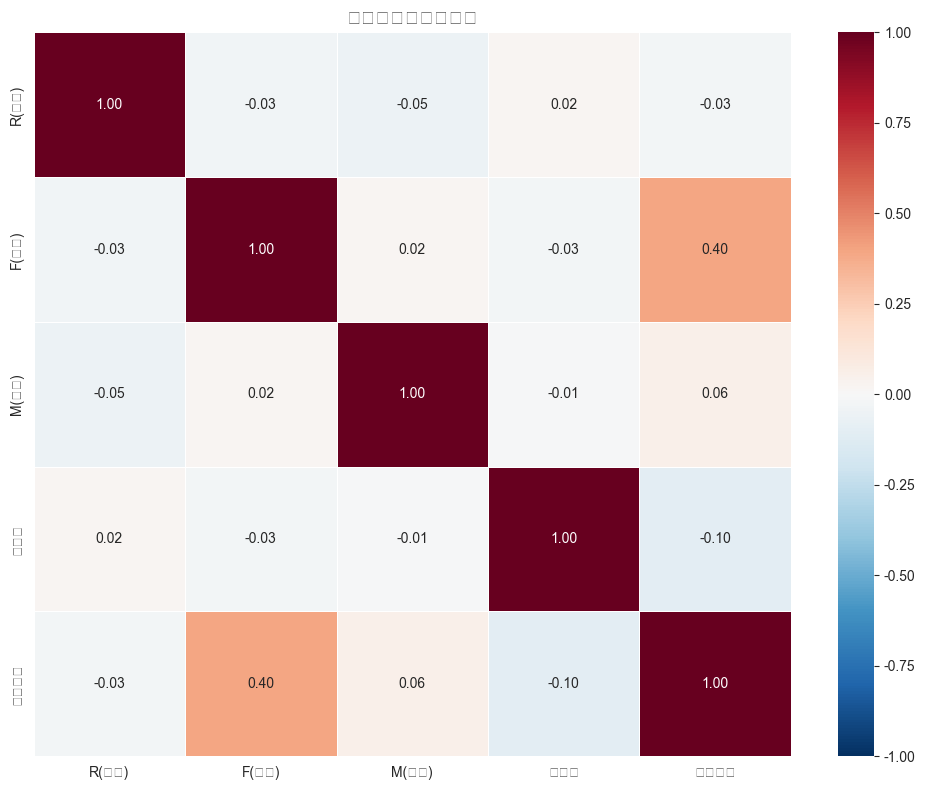

In [49]:
# 构建聚类特征矩阵
# R: Last_Login_Days_Ago (负向指标) → 取负值使方向一致(值越大表示越近)
# F: Purchase_Frequency
# M: Total_Spending
# Intent: Intent_Score
# Friction: Conversion_Friction

cluster_features = pd.DataFrame({
    'R': -df['Last_Login_Days_Ago'],
    'F': df['Purchase_Frequency'],
    'M': df['Total_Spending'],
    'Intent': df['Intent_Score'],
    'Friction': df['Conversion_Friction']
})

print('聚类特征矩阵 (前10行):')
display(cluster_features.head(10))
print(f'特征矩阵形状: {cluster_features.shape}')

# 特征相关性热力图
fig, ax = plt.subplots(figsize=(10, 8))
corr = cluster_features.corr()
corr_renamed = corr.rename(
    columns={'R':'R(近度)','F':'F(频次)','M':'M(金额)','Intent':'意向度','Friction':'转化摩擦'},
    index={'R':'R(近度)','F':'F(频次)','M':'M(金额)','Intent':'意向度','Friction':'转化摩擦'}
)
sns.heatmap(corr_renamed, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('五维特征相关性矩阵', fontsize=14)
plt.tight_layout()
plt.show()


In [50]:
# Z-Score 标准化
scaler = StandardScaler()
features_scaled = scaler.fit_transform(cluster_features)
features_scaled_df = pd.DataFrame(features_scaled, columns=cluster_features.columns)

print('标准化后各特征统计 (均值≈0, 标准差≈1):')
display(features_scaled_df.describe().round(3))


标准化后各特征统计 (均值≈0, 标准差≈1):


,R,F,M,Intent,Friction
count,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.000,-0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001
min,-1.636,-1.633,-1.719,-1.809,-0.701
25%,-0.904,-0.928,-0.902,-0.857,-0.511
50%,-0.050,0.130,-0.008,-0.030,-0.305
75%,0.925,0.835,0.903,0.870,0.050
max,1.778,1.540,1.722,1.818,9.022


---
## 3. 确定最佳聚类数 K


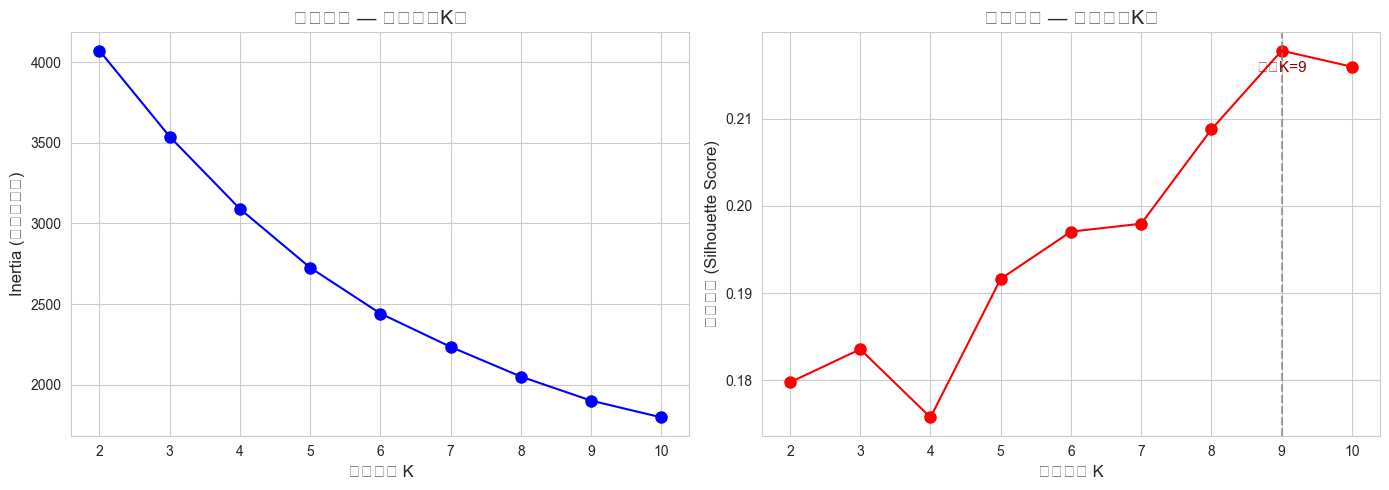

最佳聚类数 K = 9 (轮廓系数: 0.2178)
  K=2: 轮廓系数=0.1798
  K=3: 轮廓系数=0.1836
  K=4: 轮廓系数=0.1757
  K=5: 轮廓系数=0.1916
  K=6: 轮廓系数=0.1970
  K=7: 轮廓系数=0.1980
  K=8: 轮廓系数=0.2088
  K=9: 轮廓系数=0.2178  ← 最佳
  K=10: 轮廓系数=0.2160


In [51]:
# 肘部法则 + 轮廓系数联合判断
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 肘部法则
ax1.plot(K_range, inertias, 'bo-', markersize=8)
ax1.set_xlabel('聚类数量 K', fontsize=12)
ax1.set_ylabel('Inertia (簇内平方和)', fontsize=12)
ax1.set_title('肘部法则 — 确定最佳K值', fontsize=14)

# 轮廓系数
ax2.plot(K_range, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('聚类数量 K', fontsize=12)
ax2.set_ylabel('轮廓系数 (Silhouette Score)', fontsize=12)
ax2.set_title('轮廓系数 — 确定最佳K值', fontsize=14)
best_k = K_range[np.argmax(silhouette_scores)]
ax2.axvline(best_k, color='gray', linestyle='--', alpha=0.7)
ax2.annotate(f'最佳K={best_k}', (best_k, max(silhouette_scores)),
             textcoords='offset points', xytext=(0,-15),
             ha='center', fontsize=11, color='darkred')

plt.tight_layout()
plt.show()

print(f'最佳聚类数 K = {best_k} (轮廓系数: {max(silhouette_scores):.4f})')
for k, sil in zip(K_range, silhouette_scores):
    marker = '  ← 最佳' if k == best_k else ''
    print(f'  K={k}: 轮廓系数={sil:.4f}{marker}')


---
## 4. K-Means 聚类（增强RFM五维模型）


In [52]:
# 使用最佳K值进行聚类
optimal_k = best_k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_Enhanced'] = kmeans.fit_predict(features_scaled)

print(f'聚类完成，共 {optimal_k} 个群体')
print()
print('各群体数量分布:')
counts = df['Cluster_Enhanced'].value_counts().sort_index()
for cid, cnt in counts.items():
    bar = '#' * (cnt // 5)
    print(f'  群体 {cid}: {cnt:4d}人 ({cnt/len(df)*100:5.1f}%) {bar}')
print(f'群体规模标准差: {counts.std():.0f}人 (越小越均衡)')


聚类完成，共 9 个群体

各群体数量分布:
  群体 0:  104人 ( 10.4%) ####################
  群体 1:  129人 ( 12.9%) #########################
  群体 2:  129人 ( 12.9%) #########################
  群体 3:   99人 (  9.9%) ###################
  群体 4:  132人 ( 13.2%) ##########################
  群体 5:  127人 ( 12.7%) #########################
  群体 6:  102人 ( 10.2%) ####################
  群体 7:  131人 ( 13.1%) ##########################
  群体 8:   47人 (  4.7%) #########
群体规模标准差: 28人 (越小越均衡)


In [53]:
# 各聚类中心（还原到原始量纲）
centers_scaled = kmeans.cluster_centers_
centers_orig = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_orig, columns=cluster_features.columns)
# 还原R为原始天数
centers_df['Last_Login_Days_Ago'] = -centers_df['R']
centers_df = centers_df.drop(columns=['R'])

print('=== 各聚类中心（原始量纲）===')
display(centers_df.round(2))


=== 各聚类中心（原始量纲）===


,F,M,Intent,Friction,Last_Login_Days_Ago
0,2.44,3507.39,228.36,0.12,8.55
1,7.06,1578.91,229.19,0.37,9.88
2,7.06,3726.22,217.02,0.38,21.86
3,6.56,3674.76,84.48,0.33,8.77
4,2.23,3771.83,98.08,0.12,20.99
5,2.05,1606.34,250.31,0.10,19.42
6,2.51,1248.86,94.25,0.15,7.36
7,5.97,1292.86,86.86,0.36,22.90
8,6.68,3008.32,116.57,1.96,15.89


=== 各群体画像均值对比 ===


,Last_Login_Days_Ago,Purchase_Frequency,Total_Spending,Intent_Score,Conversion_Friction,Time_Spent_on_Site_Minutes,Pages_Viewed,Average_Order_Value,用户数,占比%
Cluster_Enhanced,,,,,,,,,,
0,8.55,2.44,3507.39,228.36,0.12,430.76,25.95,110.62,104,10.4
1,9.88,7.06,1578.91,229.19,0.37,432.06,26.32,99.37,129,12.9
2,21.86,7.06,3726.22,217.02,0.38,409.27,24.78,106.72,129,12.9
3,8.77,6.56,3674.76,84.48,0.33,142.70,26.27,112.01,99,9.9
4,20.99,2.23,3771.83,98.08,0.12,170.86,25.30,106.30,132,13.2
5,19.42,2.05,1606.34,250.31,0.10,473.80,26.82,102.96,127,12.7
6,7.36,2.51,1248.86,94.25,0.15,163.61,24.90,98.70,102,10.2
7,22.90,5.97,1292.86,86.86,0.36,150.08,23.65,102.40,131,13.1
8,15.89,6.68,3008.32,116.57,1.96,230.40,2.74,90.89,47,4.7


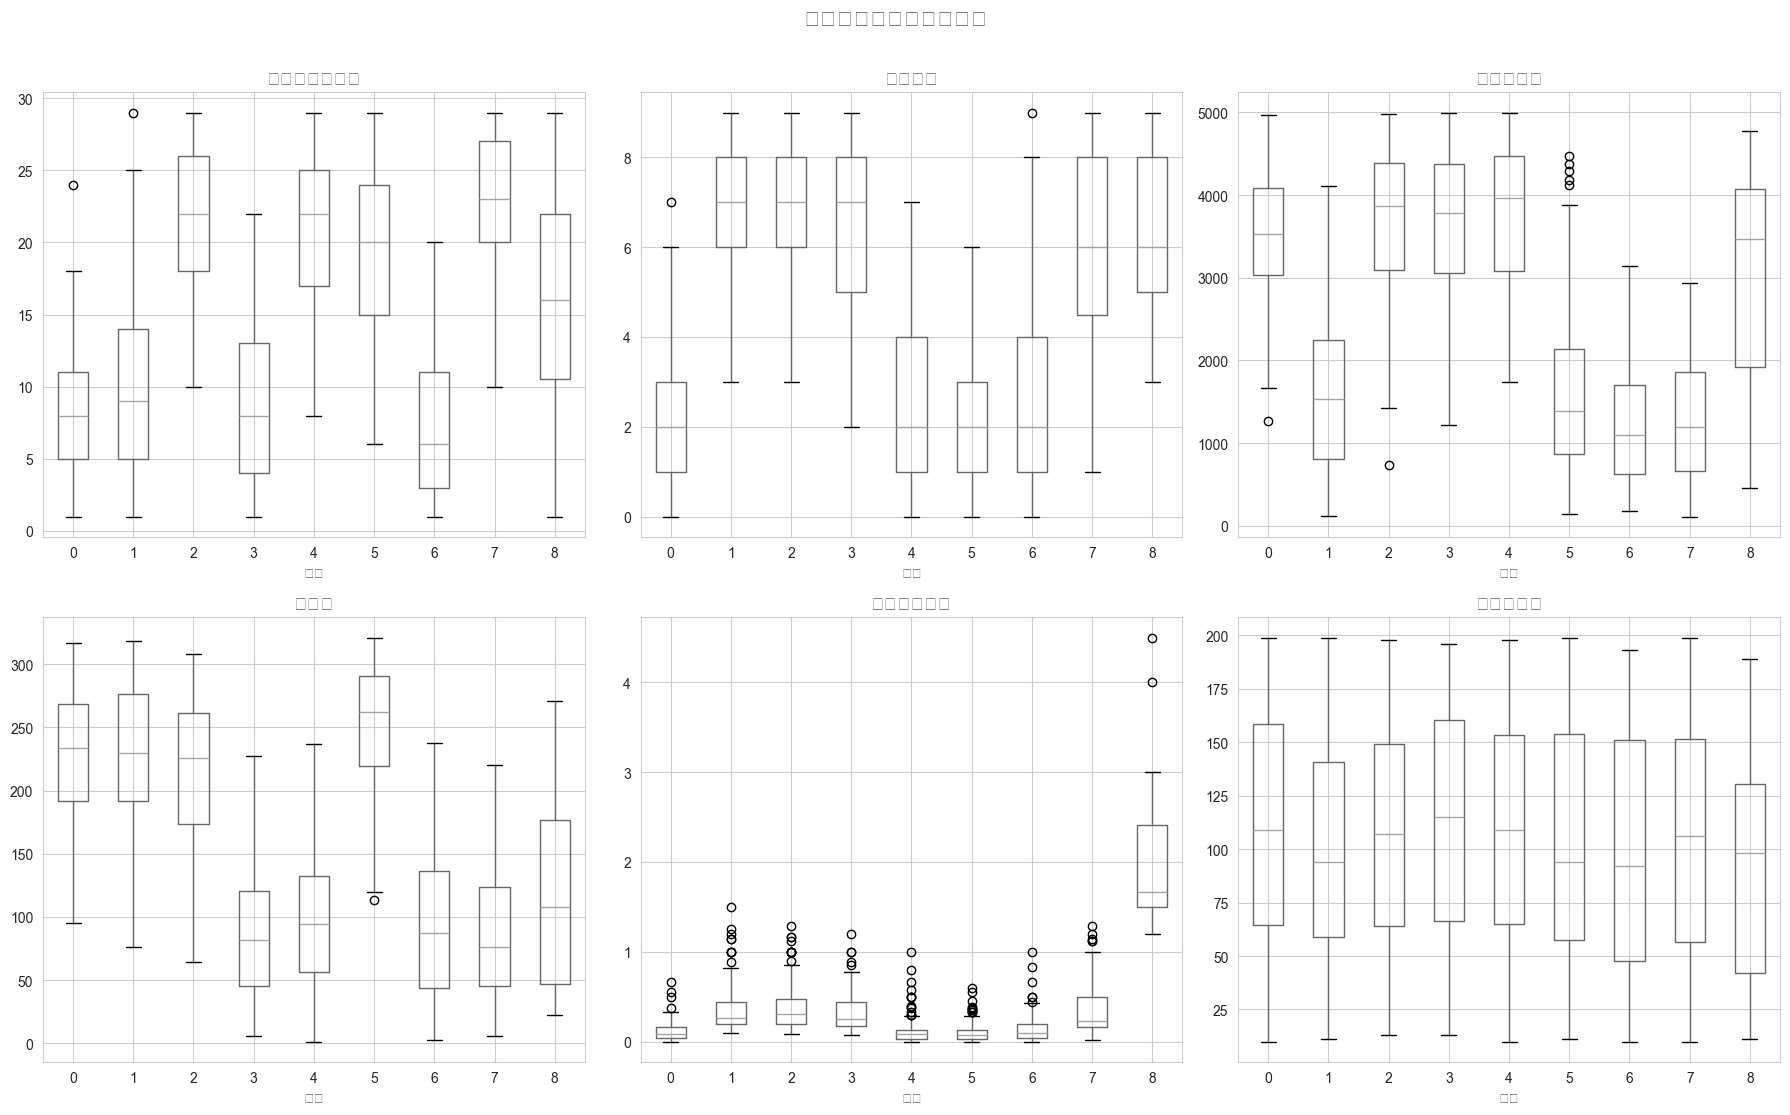

In [54]:
# 各群体全维度画像
profile_cols = ['Last_Login_Days_Ago','Purchase_Frequency','Total_Spending',
                'Intent_Score','Conversion_Friction',
                'Time_Spent_on_Site_Minutes','Pages_Viewed','Average_Order_Value']
cluster_profile = df.groupby('Cluster_Enhanced')[profile_cols].mean()
cluster_profile['用户数'] = df['Cluster_Enhanced'].value_counts().sort_index()
cluster_profile['占比%'] = (df['Cluster_Enhanced'].value_counts(normalize=True).sort_index()*100).round(1)

print('=== 各群体画像均值对比 ===')
display(cluster_profile.round(2))

# 箱线图
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
box_cols = ['Last_Login_Days_Ago','Purchase_Frequency','Total_Spending',
            'Intent_Score','Conversion_Friction','Average_Order_Value']
box_titles = ['距上次登录天数','购买频次','总消费金额','意向度','转化摩擦系数','平均客单价']
for i, (col, title) in enumerate(zip(box_cols, box_titles)):
    ax = axes[i//3, i%3]
    df.boxplot(column=col, by='Cluster_Enhanced', ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('群体')
plt.suptitle('各群体关键指标分布对比', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


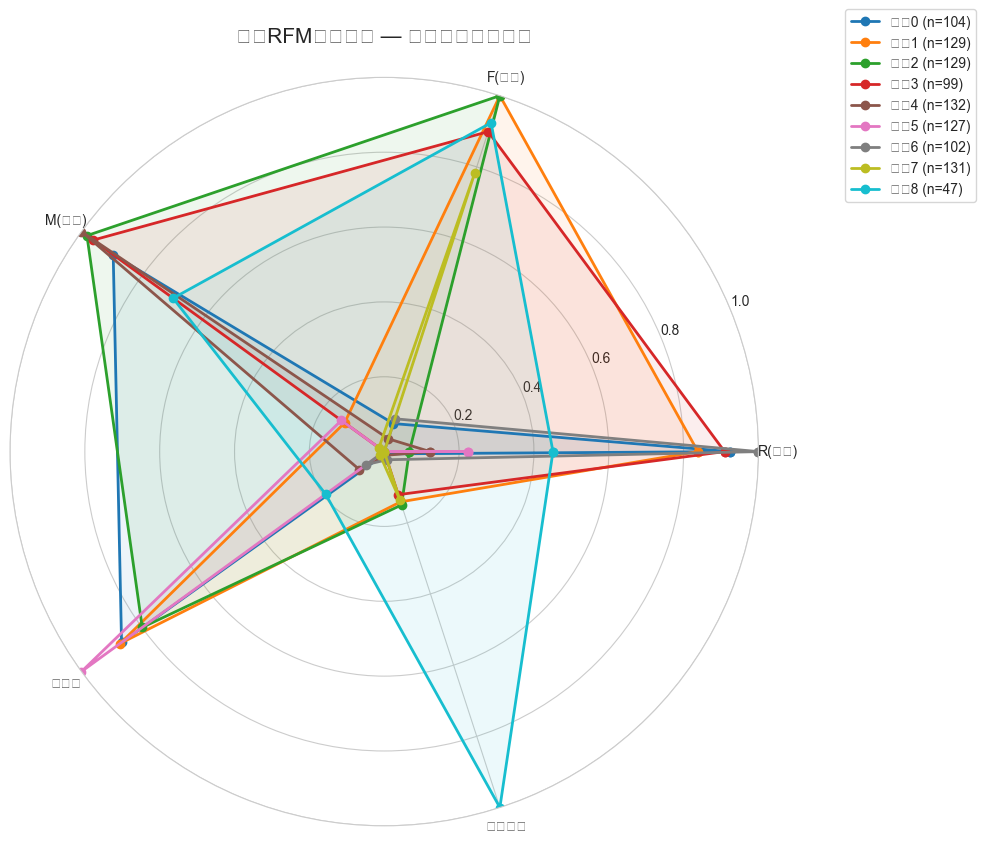

In [55]:
# 雷达图：各群体五维画像对比
radar_labels = ['R(近度)','F(频次)','M(金额)','意向度','转化效率']
radar_data = pd.DataFrame(centers_scaled, columns=cluster_features.columns)

mms = MinMaxScaler()
radar_norm = pd.DataFrame(mms.fit_transform(radar_data), columns=radar_labels)

angles = np.linspace(0, 2*np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    values = radar_norm.iloc[i].tolist()
    values += values[:1]
    size = df['Cluster_Enhanced'].value_counts().sort_index().iloc[i]
    ax.plot(angles, values, 'o-', color=colors[i], linewidth=2, markersize=6,
            label=f'群体{i} (n={size})')
    ax.fill(angles, values, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('增强RFM五维聚类 — 各群体画像雷达图', fontsize=15, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()


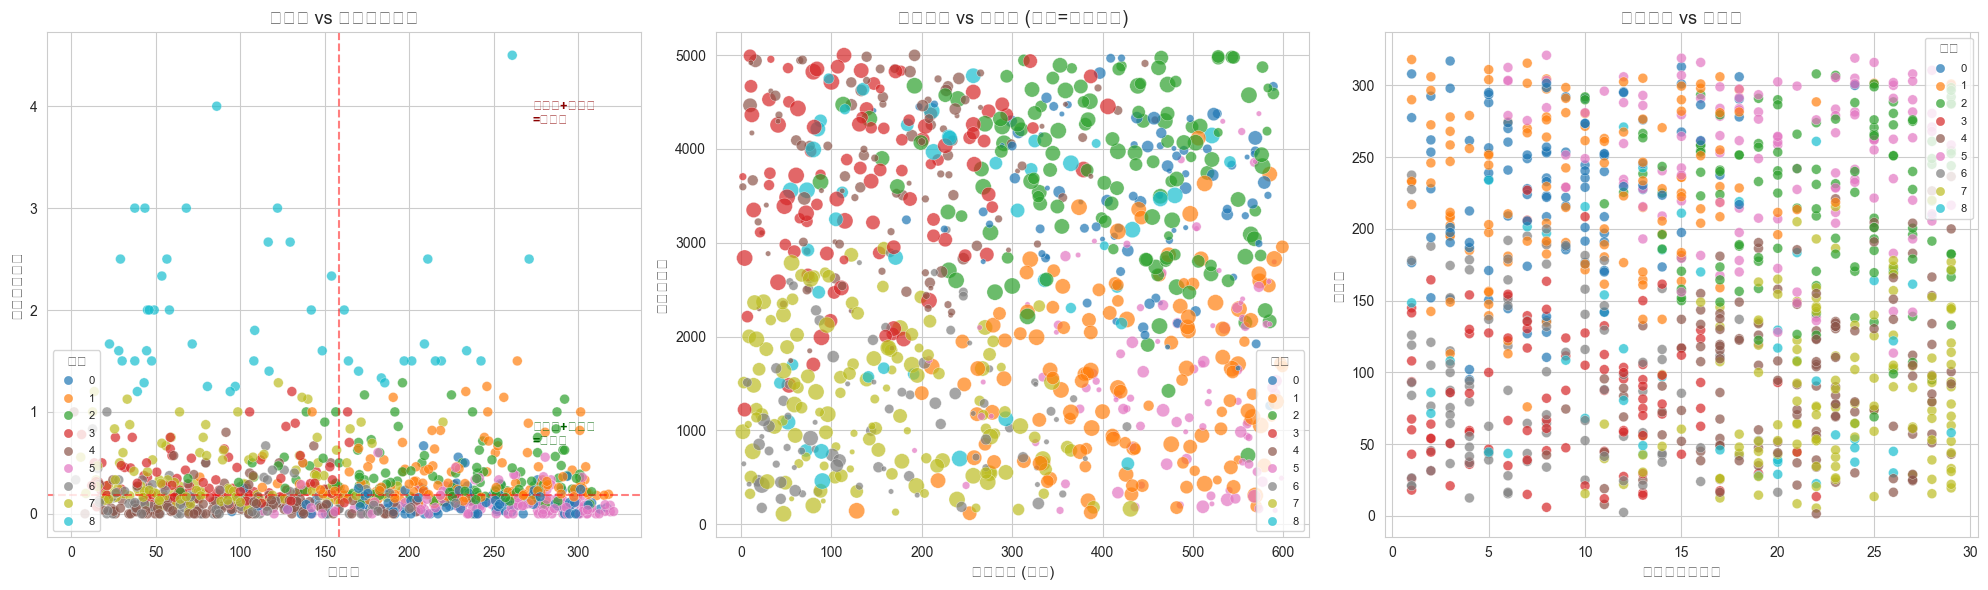

In [56]:
# 二维散点图：三个关键视角
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 图1：意向度 vs 转化摩擦系数
s1 = axes[0].scatter(df['Intent_Score'], df['Conversion_Friction'],
                     c=df['Cluster_Enhanced'], cmap='tab10', alpha=0.7,
                     s=50, edgecolors='white', linewidth=0.3)
axes[0].axhline(df['Conversion_Friction'].median(), color='red', ls='--', alpha=0.5)
axes[0].axvline(df['Intent_Score'].median(), color='red', ls='--', alpha=0.5)
axes[0].set_xlabel('意向度', fontsize=11)
axes[0].set_ylabel('转化摩擦系数', fontsize=11)
axes[0].set_title('意向度 vs 转化摩擦系数', fontsize=13)
axes[0].annotate('高意向+高摩擦\n=有潜力', xy=(df['Intent_Score'].max()*0.85, df['Conversion_Friction'].max()*0.15),
                fontsize=9, color='darkgreen', fontweight='bold')
axes[0].annotate('高意向+低摩擦\n=待转化', xy=(df['Intent_Score'].max()*0.85, df['Conversion_Friction'].max()*0.85),
                fontsize=9, color='darkred', fontweight='bold')
axes[0].legend(*s1.legend_elements(), title='群体', loc='lower left', fontsize=8)

# 图2：浏览时长 vs 总消费（气泡=购买频次）
s2 = axes[1].scatter(df['Time_Spent_on_Site_Minutes'], df['Total_Spending'],
                     c=df['Cluster_Enhanced'], cmap='tab10', alpha=0.7,
                     s=df['Purchase_Frequency']*15, edgecolors='white', linewidth=0.3)
axes[1].set_xlabel('浏览时长 (分钟)', fontsize=11)
axes[1].set_ylabel('总消费金额', fontsize=11)
axes[1].set_title('浏览时长 vs 总消费 (气泡=购买频次)', fontsize=13)
axes[1].legend(*s2.legend_elements(), title='群体', loc='lower right', fontsize=8)

# 图3：距上次登录天数 vs 意向度
s3 = axes[2].scatter(df['Last_Login_Days_Ago'], df['Intent_Score'],
                     c=df['Cluster_Enhanced'], cmap='tab10', alpha=0.7,
                     s=50, edgecolors='white', linewidth=0.3)
axes[2].set_xlabel('距上次登录天数', fontsize=11)
axes[2].set_ylabel('意向度', fontsize=11)
axes[2].set_title('最近登录 vs 意向度', fontsize=13)
axes[2].legend(*s3.legend_elements(), title='群体', loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


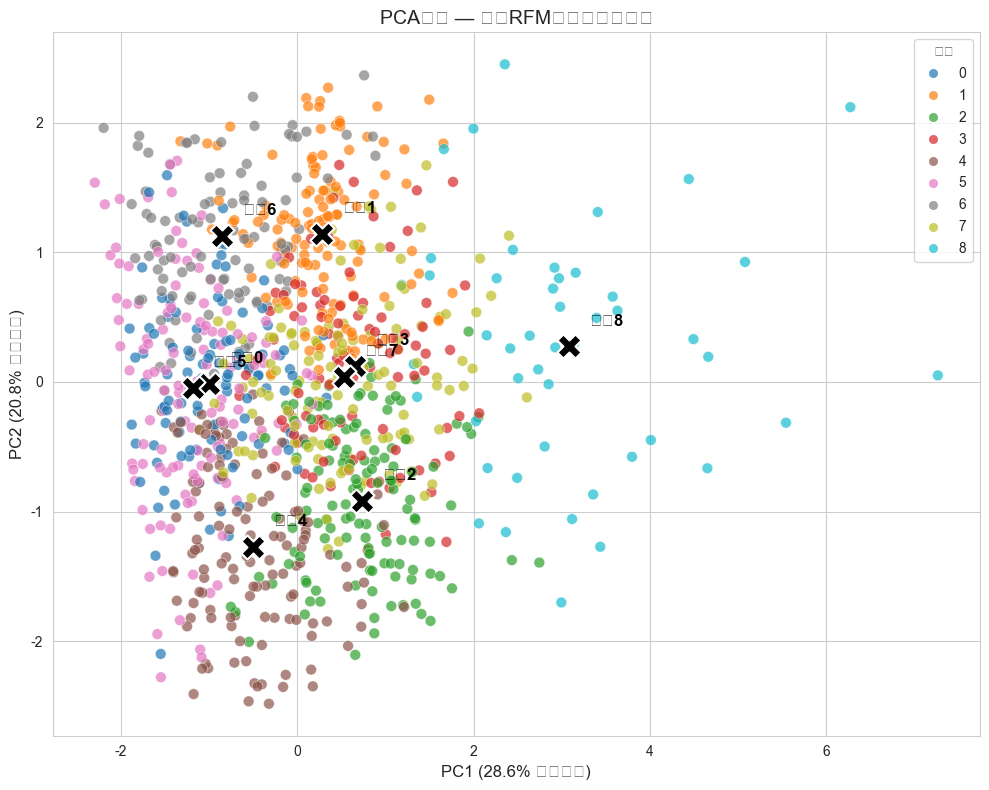

PCA前两个主成分累计方差解释率: 49.42%
各特征对主成分的载荷:


,PC1,PC2
R(近度),-0.125,0.699
F(频次),0.665,0.170
M(金额),0.144,-0.683
意向度,-0.214,0.038
转化摩擦,0.690,0.117


In [57]:
# PCA降维可视化
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_pca[:,0], features_pca[:,1],
                      c=df['Cluster_Enhanced'], cmap='tab10', alpha=0.7,
                      s=60, edgecolors='white', linewidth=0.4)

# 聚类中心
pca_centers = pca.transform(centers_scaled)
plt.scatter(pca_centers[:,0], pca_centers[:,1],
            c='black', marker='X', s=300, edgecolors='white', linewidth=1.5,
            label='聚类中心', zorder=5)
for i, (x, y) in enumerate(pca_centers):
    plt.annotate(f'群体{i}', (x, y), textcoords='offset points', xytext=(15,15),
                 fontsize=12, fontweight='bold', color='black')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} 方差解释)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} 方差解释)', fontsize=12)
plt.title('PCA降维 — 增强RFM五维聚类可视化', fontsize=14)
plt.legend(*scatter.legend_elements(), title='群体', loc='upper right')
plt.tight_layout()
plt.show()

print(f'PCA前两个主成分累计方差解释率: {pca.explained_variance_ratio_.sum():.2%}')

# 各特征对主成分的载荷
loadings = pd.DataFrame(pca.components_.T, columns=['PC1','PC2'],
    index=['R(近度)','F(频次)','M(金额)','意向度','转化摩擦'])
print('各特征对主成分的载荷:')
display(loadings.round(3))


---
## 5. 群体解读与业务标签


In [58]:
# 各群体五维排名
rank_df = pd.DataFrame()
rank_df['Recency排名'] = cluster_profile['Last_Login_Days_Ago'].rank(ascending=False)
rank_df['Frequency排名'] = cluster_profile['Purchase_Frequency'].rank(ascending=True)
rank_df['Monetary排名'] = cluster_profile['Total_Spending'].rank(ascending=True)
rank_df['Intent排名'] = cluster_profile['Intent_Score'].rank(ascending=True)
rank_df['Friction排名'] = cluster_profile['Conversion_Friction'].rank(ascending=True)
rank_df['综合得分'] = rank_df.mean(axis=1)
rank_df['综合排名'] = rank_df['综合得分'].rank(ascending=False).astype(int)

print('=== 各群体五维排名 (值越大排名越靠前) ===')
display(rank_df.round(1))

# 自动生成群体业务标签
avg_freq = df['Purchase_Frequency'].mean()
avg_spend = df['Total_Spending'].mean()
avg_intent = df['Intent_Score'].mean()
avg_recency = df['Last_Login_Days_Ago'].mean()
avg_fric = df['Conversion_Friction'].mean()

def label_cluster(row):
    recent = row['Last_Login_Days_Ago'] < avg_recency
    hi_f = row['Purchase_Frequency'] > avg_freq
    hi_m = row['Total_Spending'] > avg_spend
    hi_intent = row['Intent_Score'] > avg_intent
    hi_fric = row['Conversion_Friction'] > avg_fric

    if recent and hi_f and hi_m:
        return '高价值核心用户'
    elif recent and hi_f and not hi_m:
        return '高频活跃用户'
    elif hi_intent and not hi_f:
        if hi_fric:
            return '高意向待转化(低摩擦)'
        else:
            return '潜水/摩擦型用户'
    elif hi_m and not recent:
        return '高价值流失预警'
    elif not recent and not hi_f and not hi_m:
        return '沉默低价值用户'
    elif recent and not hi_f:
        return '新晋/活跃探索用户'
    else:
        return '一般维持型用户'

cluster_profile['群体标签'] = cluster_profile.apply(label_cluster, axis=1)

print('=== 群体画像与业务标签 ===')
display(cluster_profile[['用户数','占比%','Last_Login_Days_Ago','Purchase_Frequency',
                         'Total_Spending','Intent_Score','Conversion_Friction','群体标签']])


=== 各群体五维排名 (值越大排名越靠前) ===


,Recency排名,Frequency排名,Monetary排名,Intent排名,Friction排名,综合得分,综合排名
Cluster_Enhanced,,,,,,,
0,8.0,3.0,6.0,7.0,2.0,5.2,4
1,6.0,8.5,3.0,8.0,7.0,6.5,1
2,2.0,8.5,8.0,6.0,8.0,6.5,1
3,7.0,6.0,7.0,1.0,5.0,5.2,4
4,3.0,2.0,9.0,4.0,3.0,4.2,6
5,4.0,1.0,4.0,9.0,1.0,3.8,8
6,9.0,4.0,1.0,3.0,4.0,4.2,6
7,1.0,5.0,2.0,2.0,6.0,3.2,9
8,5.0,7.0,5.0,5.0,9.0,6.2,3


=== 群体画像与业务标签 ===


,用户数,占比%,Last_Login_Days_Ago,Purchase_Frequency,Total_Spending,Intent_Score,Conversion_Friction,群体标签
Cluster_Enhanced,,,,,,,,
0,104,10.4,8.548077,2.442308,3507.394231,228.355769,0.115538,潜水/摩擦型用户
1,129,12.9,9.875969,7.062016,1578.906977,229.189922,0.366280,高频活跃用户
2,129,12.9,21.860465,7.062016,3726.217054,217.023256,0.382483,高价值流失预警
3,99,9.9,8.767677,6.555556,3674.757576,84.484848,0.328867,高价值核心用户
4,132,13.2,20.992424,2.227273,3771.825758,98.075758,0.123046,高价值流失预警
5,127,12.7,19.417323,2.047244,1606.338583,250.307087,0.103618,潜水/摩擦型用户
6,102,10.2,7.362745,2.509804,1248.862745,94.254902,0.146327,新晋/活跃探索用户
7,131,13.1,22.900763,5.969466,1292.862595,86.862595,0.357556,一般维持型用户
8,47,4.7,15.893617,6.680851,3008.319149,116.574468,1.963931,高价值流失预警


---
## 6. 与传统RFM模型对比

使用相同的K值，仅用R/F/M三维进行聚类，对比两个模型的差异。
重点看：**传统RFM判为"低价值"的用户中，有多少实际上是高意向的潜水用户。**


In [59]:
# 传统RFM聚类 (仅R/F/M三维)
rfm_features = cluster_features[['R','F','M']]
rfm_scaled = StandardScaler().fit_transform(rfm_features)

kmeans_rfm = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_RFM'] = kmeans_rfm.fit_predict(rfm_scaled)

print('=== 传统RFM (3维) vs 增强RFM (5维) 交叉对比 ===')
cross = pd.crosstab(
    [f'RFM-群体{c}' for c in df['Cluster_RFM']],
    [f'增强-群体{c}' for c in df['Cluster_Enhanced']],
    margins=True, margins_name='合计'
)
display(cross)

agree = (df['Cluster_RFM'] == df['Cluster_Enhanced']).mean()
print(f'两个模型标签一致的用户比例: {agree:.1%}')
print(f'两个模型标签不同的用户数量: {len(df) - (df["Cluster_RFM"]==df["Cluster_Enhanced"]).sum()}')


=== 传统RFM (3维) vs 增强RFM (5维) 交叉对比 ===


col_0,增强-群体0,增强-群体1,增强-群体2,增强-群体3,增强-群体4,增强-群体5,增强-群体6,增强-群体7,增强-群体8,合计
row_0,,,,,,,,,,
RFM-群体0,0,48,6,5,1,4,6,30,9,109
RFM-群体1,0,0,0,0,19,67,10,27,1,124
RFM-群体2,17,8,27,63,5,0,0,0,13,133
RFM-群体3,11,8,0,0,0,24,63,0,0,106
RFM-群体4,9,0,8,0,83,18,0,1,1,120
RFM-群体5,67,1,0,10,14,2,13,0,2,109
RFM-群体6,0,58,0,17,0,0,10,1,4,90
RFM-群体7,0,0,77,4,9,0,0,6,13,109
RFM-群体8,0,6,11,0,1,12,0,66,4,100


两个模型标签一致的用户比例: 13.2%
两个模型标签不同的用户数量: 868


In [60]:
# 关键发现：传统RFM判为"低价值"的用户，在增强模型中的去向
rfm_prof = df.groupby('Cluster_RFM')[['Last_Login_Days_Ago','Purchase_Frequency','Total_Spending']].mean()
rfm_prof['rank_score'] = (rfm_prof['Last_Login_Days_Ago'].rank(ascending=False) +
                           rfm_prof['Purchase_Frequency'].rank() +
                           rfm_prof['Total_Spending'].rank())
rfm_low_idx = rfm_prof['rank_score'].idxmin()

low_rfm = df[df['Cluster_RFM'] == rfm_low_idx]
print(f'传统RFM判为"低价值"的用户: {len(low_rfm)}人 ({len(low_rfm)/len(df)*100:.1f}%)')
print()
print('这些用户在增强模型中的分布:')
for cid, cnt in low_rfm['Cluster_Enhanced'].value_counts().sort_index().items():
    label = cluster_profile.at[cid,'群体标签'] if cid in cluster_profile.index else ''
    print(f'  增强-群体{cid} ({label}): {cnt}人 ({cnt/len(low_rfm)*100:.1f}%)')

hi_pct = (low_rfm['Intent_Score'] > df['Intent_Score'].median()).mean()
zero_pur = ((low_rfm['Purchase_Frequency']==0) & (low_rfm['Intent_Score']>df['Intent_Score'].median())).sum()
print(f'\n其中高意向用户(>中位数)占比: {hi_pct:.1%}')
print(f'其中零购买但高意向用户: {zero_pur}人')
print(f'传统RFM低价值群体意向度均值: {low_rfm.Intent_Score.mean():.0f} (全量均值: {df.Intent_Score.mean():.0f})')
print(f'传统RFM低价值群体浏览时长均值: {low_rfm.Time_Spent_on_Site_Minutes.mean():.0f}分钟 (全量均值: {df.Time_Spent_on_Site_Minutes.mean():.0f}分钟)')


传统RFM判为"低价值"的用户: 124人 (12.4%)

这些用户在增强模型中的分布:
  增强-群体4 (高价值流失预警): 19人 (15.3%)
  增强-群体5 (潜水/摩擦型用户): 67人 (54.0%)
  增强-群体6 (新晋/活跃探索用户): 10人 (8.1%)
  增强-群体7 (一般维持型用户): 27人 (21.8%)
  增强-群体8 (高价值流失预警): 1人 (0.8%)

其中高意向用户(>中位数)占比: 48.4%
其中零购买但高意向用户: 11人
传统RFM低价值群体意向度均值: 168 (全量均值: 161)
传统RFM低价值群体浏览时长均值: 311分钟 (全量均值: 297分钟)


In [61]:
# 量化对比：两个模型的群体凝聚力
sil_enh = silhouette_score(features_scaled, df['Cluster_Enhanced'])
sil_rfm = silhouette_score(rfm_scaled, df['Cluster_RFM'])

print('=' * 50)
print(f'增强RFM模型 (5维) 轮廓系数: {sil_enh:.4f}')
print(f'传统RFM模型 (3维) 轮廓系数: {sil_rfm:.4f}')
direction = '提升' if sil_enh > sil_rfm else '下降'
print(f'{direction}: {abs(sil_enh-sil_rfm):.4f}')

# 对比高意向低购买用户在两个模型中的分布
hi_low = df[(df['Intent_Score']>df['Intent_Score'].median()) &
            (df['Purchase_Frequency']<df['Purchase_Frequency'].median())]

print(f'\n高意向低购买用户总数: {len(hi_low)}人')
print('\n传统RFM中这些用户的群体分布:')
for cid, pct in hi_low['Cluster_RFM'].value_counts(normalize=True).mul(100).round(1).items():
    print(f'  RFM-群体{cid}: {pct}%')

print('\n增强RFM中这些用户的群体分布:')
for cid, pct in hi_low['Cluster_Enhanced'].value_counts(normalize=True).mul(100).round(1).items():
    label = cluster_profile.at[cid,'群体标签'] if cid in cluster_profile.index else ''
    print(f'  增强-群体{cid} ({label}): {pct}%')

print()
print('✅ 增强模型能更精准地将"高意向低购买"用户分离到独立群体，便于后续针对性运营')


增强RFM模型 (5维) 轮廓系数: 0.2178
传统RFM模型 (3维) 轮廓系数: 0.2799
下降: 0.0621

高意向低购买用户总数: 234人

传统RFM中这些用户的群体分布:
  RFM-群体1: 25.6%
  RFM-群体5: 25.6%
  RFM-群体3: 25.2%
  RFM-群体4: 21.4%
  RFM-群体8: 1.3%
  RFM-群体0: 0.9%

增强RFM中这些用户的群体分布:
  增强-群体5 (潜水/摩擦型用户): 44.9%
  增强-群体0 (潜水/摩擦型用户): 32.1%
  增强-群体6 (新晋/活跃探索用户): 7.3%
  增强-群体4 (高价值流失预警): 6.4%
  增强-群体1 (高频活跃用户): 3.8%
  增强-群体2 (高价值流失预警): 3.4%
  增强-群体8 (高价值流失预警): 1.3%
  增强-群体7 (一般维持型用户): 0.9%

✅ 增强模型能更精准地将"高意向低购买"用户分离到独立群体，便于后续针对性运营


---
## 7. 可落地的运营策略

基于增强RFM聚类结果，为每个群体制定差异化运营方案。


In [62]:
# 为每个群体生成精细化运营策略
strategy_map = {
    '高价值核心用户': [
        'VIP会员升级邀请，提供专属客服通道',
        '高客单价新品优先推荐 + 限量/联名款触达',
        '生日/节日高端礼品关怀，增强情感连接',
        '邀请参与产品内测和用户调研，提升参与感',
        '专属折扣码 + 会员日双倍积分'
    ],
    '高频活跃用户': [
        '满额返券，激励提升客单价至均值以上',
        '跨品类推荐 (如从Apparel拓展到Electronics)',
        '组合套餐/捆绑销售，提升单次消费金额'
    ],
    '高意向待转化(低摩擦)': [
        '⭐ 首单大额优惠券/满减券，降低首次购买门槛',
        '基于浏览历史的个性化商品推荐邮件',
        '限时闪购/秒杀活动推送，制造紧迫感',
        '购物车加购未付款的召回提醒',
        '展示"X人已购买"等社会证明元素'
    ],
    '潜水/摩擦型用户': [
        '分析浏览路径瓶颈，优化详情页和支付流程',
        '商品测评/买家秀/UGC内容推送，增强购买信心',
        '在线客服主动触达("看到您在浏览XX，有什么可以帮您?")',
        'A/B测试不同优惠力度，找到转化拐点',
        '对比价格优势/售后保障等打消顾虑的内容'
    ],
    '高价值流失预警': [
        '🔥 客服/客户经理主动回访，了解流失原因',
        '大力度回归优惠券 (满减+包邮双重激励)',
        '"我们想念你"情感化召回邮件 + 新品推荐',
        '老用户专享折扣/早鸟价，强化被重视感',
        '推送品类更新/品牌升级信息，刷新品牌认知'
    ],
    '新晋/活跃探索用户': [
        '新用户引导流程优化，降低认知成本',
        '品类教育内容推送 (穿搭指南/使用教程/搭配推荐)',
        '新手礼包/首单立减，推动首次购买',
        '引导完成首次购买后给予好评返现/积分奖励',
        '签到打卡/每日任务等轻互动培养习惯'
    ],
    '沉默低价值用户': [
        '低成本触达 (Push/短信)，测试是否可唤醒',
        '仅大促节点统一推送，减少日常打扰',
        '若持续3个月无响应则降级触达频率',
        '预留预算有限的"惊喜券"，随机发放测试唤醒'
    ],
}

def get_strategies(label):
    for key, strats in strategy_map.items():
        if key in label:
            return strats
    return ['常规营销自动化触达', '持续观察行为变化，等待升级信号']

cluster_profile['运营策略'] = cluster_profile['群体标签'].apply(get_strategies)

print('=== 各群体精细化运营策略 ===')
for idx, row in cluster_profile.iterrows():
    print(f'\n{"="*60}')
    print(f'【群体{idx}】{row["群体标签"]}')
    print(f'  规模: {int(row["用户数"])}人 ({row["占比%"]}%)')
    print(f'  画像: R={row["Last_Login_Days_Ago"]:.0f}天前 | F={row["Purchase_Frequency"]:.1f}次 | M=¥{row["Total_Spending"]:.0f} | 意向度={row["Intent_Score"]:.0f} | 摩擦={row["Conversion_Friction"]:.3f}')
    print(f'  策略:')
    for s in row['运营策略']:
        print(f'    • {s}')


=== 各群体精细化运营策略 ===

【群体0】潜水/摩擦型用户
  规模: 104人 (10.4%)
  画像: R=9天前 | F=2.4次 | M=¥3507 | 意向度=228 | 摩擦=0.116
  策略:
    • 分析浏览路径瓶颈，优化详情页和支付流程
    • 商品测评/买家秀/UGC内容推送，增强购买信心
    • 在线客服主动触达("看到您在浏览XX，有什么可以帮您?")
    • A/B测试不同优惠力度，找到转化拐点
    • 对比价格优势/售后保障等打消顾虑的内容

【群体1】高频活跃用户
  规模: 129人 (12.9%)
  画像: R=10天前 | F=7.1次 | M=¥1579 | 意向度=229 | 摩擦=0.366
  策略:
    • 满额返券，激励提升客单价至均值以上
    • 跨品类推荐 (如从Apparel拓展到Electronics)
    • 组合套餐/捆绑销售，提升单次消费金额

【群体2】高价值流失预警
  规模: 129人 (12.9%)
  画像: R=22天前 | F=7.1次 | M=¥3726 | 意向度=217 | 摩擦=0.382
  策略:
    • 🔥 客服/客户经理主动回访，了解流失原因
    • 大力度回归优惠券 (满减+包邮双重激励)
    • "我们想念你"情感化召回邮件 + 新品推荐
    • 老用户专享折扣/早鸟价，强化被重视感
    • 推送品类更新/品牌升级信息，刷新品牌认知

【群体3】高价值核心用户
  规模: 99人 (9.9%)
  画像: R=9天前 | F=6.6次 | M=¥3675 | 意向度=84 | 摩擦=0.329
  策略:
    • VIP会员升级邀请，提供专属客服通道
    • 高客单价新品优先推荐 + 限量/联名款触达
    • 生日/节日高端礼品关怀，增强情感连接
    • 邀请参与产品内测和用户调研，提升参与感
    • 专属折扣码 + 会员日双倍积分

【群体4】高价值流失预警
  规模: 132人 (13.2%)
  画像: R=21天前 | F=2.2次 | M=¥3772 | 意向度=98 | 摩擦=0.123
  策略:
    • 🔥 客服/客户经理主动回访，了解流失原因
    • 大力度回

In [63]:
# 导出聚类结果
df_export = df.merge(cluster_profile[['群体标签']], left_on='Cluster_Enhanced', right_index=True)
export_cols = ['User_ID','Cluster_Enhanced','群体标签',
               'Last_Login_Days_Ago','Purchase_Frequency','Total_Spending',
               'Average_Order_Value','Intent_Score','Conversion_Friction',
               'Time_Spent_on_Site_Minutes','Pages_Viewed']
df_export[export_cols].to_excel('user_segmentation_enhanced_rfm.xlsx', index=False)
print('✅ 聚类结果已导出至: user_segmentation_enhanced_rfm.xlsx')
print(f'包含 {len(export_cols)} 个字段, {len(df_export)} 条用户记录')
print(f'字段: {", ".join(export_cols)}')


✅ 聚类结果已导出至: user_segmentation_enhanced_rfm.xlsx
包含 11 个字段, 1000 条用户记录
字段: User_ID, Cluster_Enhanced, 群体标签, Last_Login_Days_Ago, Purchase_Frequency, Total_Spending, Average_Order_Value, Intent_Score, Conversion_Friction, Time_Spent_on_Site_Minutes, Pages_Viewed


---
## 8. 总结与关键发现

### 增强RFM模型 vs 传统RFM

| 对比维度 | 传统RFM (3维) | 增强RFM (5维) |
|---------|-------------|-------------|
| **聚类特征** | R, F, M | R, F, M, 意向度, 转化摩擦系数 |
| **潜水用户识别** | ❌ 误判为低价值 | ✅ 独立识别"高意向低转化"群体 |
| **运营精度** | 粗放式大群运营 | 可针对性做转化/召回/促活细分 |
| **流失预警** | 依赖R单一维度 | 结合意向度下降趋势可提前预警 |
| **新增指标含义** | — | 意向度=兴趣强度, 摩擦系数=转化难度 |

### 核心业务价值
1. **潜水用户不再被误判**：高意向低购买用户被独立识别，获得针对性转化运营
2. **减少潜在流失**：通过摩擦系数变化趋势，提前发现购买意愿下降的信号
3. **营销ROI提升**：减少对真正低价值用户的无效触达，集中资源在高潜力群体
4. **可解释性强**：两个新增指标业务含义清晰，运营团队容易理解和执行

### 下一步建议
- 定期（如每周）更新聚类结果，监控群体迁移趋势
- 对"潜水/摩擦型用户"进行A/B测试，量化转化效果
- 将意向度和摩擦系数纳入实时特征工程，支持在线推荐和个性化触达
- 结合具体商品品类，进一步细化为品类级别的RFM+模型
